In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
# Load csv file stored into:     output_path = Path("/home/clevyfidel/Documents/Workspace/RNN_paradigm/RNN/exp_seq_act_output") / model_name
# out_file = output_path / (trial_file.stem + '_activations.csv'
# out_df.to_csv(out_file, index=False)
act_df = pd.read_csv("/home/clevyfidel/Documents/Workspace/RNN_paradigm/RNN/exp_seq_act_output/population_network_all_bn8_lr0/correlation_scores/exp_trials_correlations.csv", index_col=0)
act_df.sort_values(by=['lim_std', 'd', 'tau_std'], inplace=True)

**OBS-CTX**

Effect of lim_std (no effect of tau_std, d taken individually, not shown; nor combined, shown in second plot)

<Axes: xlabel='activity_obs_ctx', ylabel='Count'>

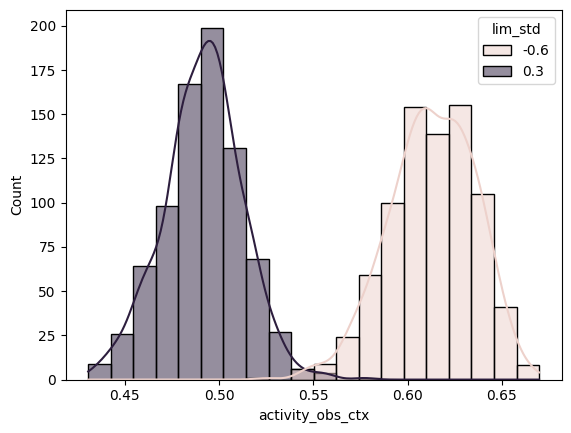

In [58]:
sns.histplot(data=act_df, x='activity_obs_ctx', bins=20, kde=True, hue='lim_std')

<Axes: xlabel='activity_obs_ctx', ylabel='Count'>

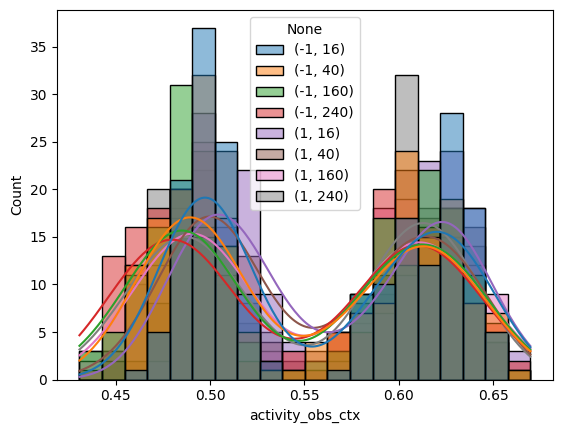

In [ ]:
sns.histplot(data=act_df, x='activity_obs_ctx', bins=20, kde=True, hue=act_df[['d', 'tau_std']].apply(tuple, axis=1))
## --> no effect of d and tau_std combined

**OBS-DPOS**

Effect of lim_std

<Axes: xlabel='activity_obs_dpos', ylabel='Count'>

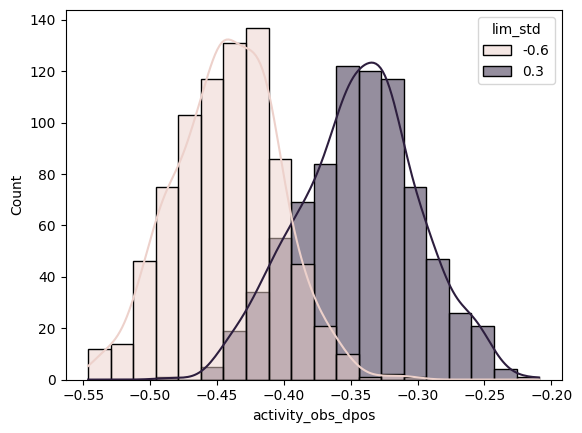

In [30]:
sns.histplot(data=act_df, x='activity_obs_dpos', bins=20, kde=True, hue='lim_std')

**CTX-DPOS**

Different distributions profiles emerge when showing all 3-level combinations  individually

2 distinct profiles emerge when showing lim_std and d combined:
- group 1: (lim_std = -0.6, d = -1) & (lim_std = 0.3, d = 1)
- group 2: (lim_std = -0.6, d = 1) & (lim_std = 0.3, d = -1)

<Axes: xlabel='activity_ctx_dpos', ylabel='Count'>

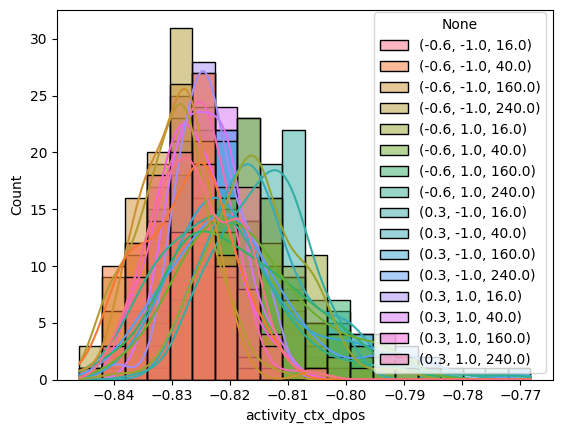

In [32]:
sns.histplot(data=act_df, x='activity_ctx_dpos', bins=20, kde=True, hue=act_df[['lim_std', 'd', 'tau_std']].apply(tuple, axis=1))

<Axes: xlabel='activity_ctx_dpos', ylabel='Count'>

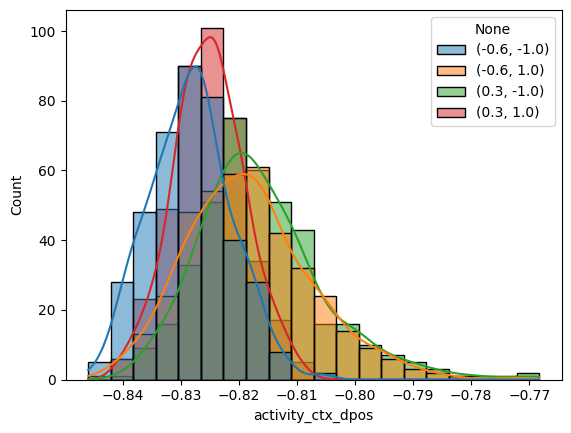

In [48]:
sns.histplot(data=act_df, x='activity_ctx_dpos', bins=20, kde=True, hue=act_df[['lim_std', 'd']].apply(tuple, axis=1))

**CTX-RULE**

Different distributions profiles emerge when showing all 3-level combinations  individually

2 distinct profiles emerge when showing lim_std and d combined:
- group 1: (lim_std = -0.6, d = -1) & (lim_std = 0.3, d = 1)
- group 2: (lim_std = -0.6, d = 1) & (lim_std = 0.3, d = -1)

<Axes: xlabel='activity_ctx_rule', ylabel='Count'>

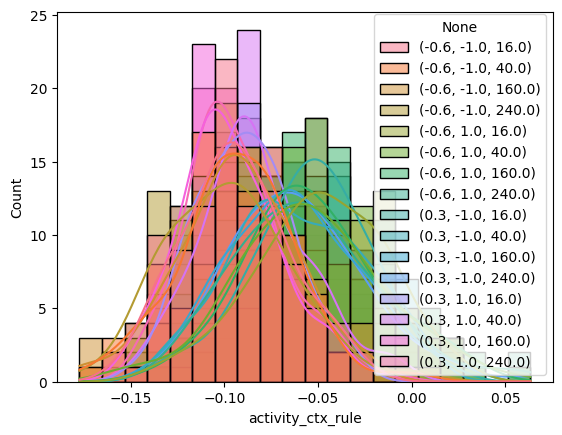

In [33]:
sns.histplot(data=act_df, x='activity_ctx_rule', bins=20, kde=True, hue=act_df[['lim_std', 'd', 'tau_std']].apply(tuple, axis=1))

<Axes: xlabel='activity_ctx_rule', ylabel='Count'>

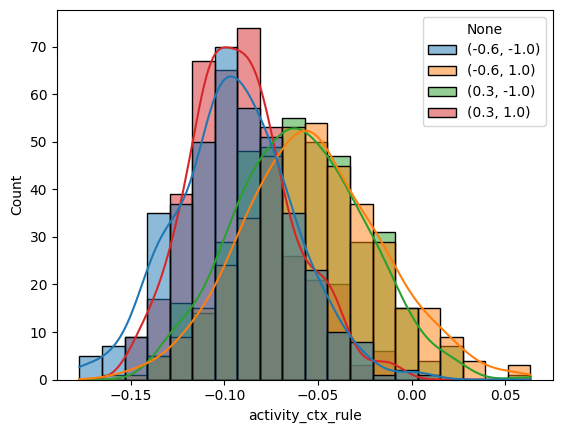

In [38]:
sns.histplot(data=act_df, x='activity_ctx_rule', bins=20, kde=True, hue=act_df[['lim_std', 'd']].apply(tuple, axis=1))

**DPOS-RULE**

No clear effect... even some 3-level combinations show bi-modal dists (-0.6, -1, 160; -0.6, 1, 160?)

<Axes: xlabel='activity_dpos_rule', ylabel='Count'>

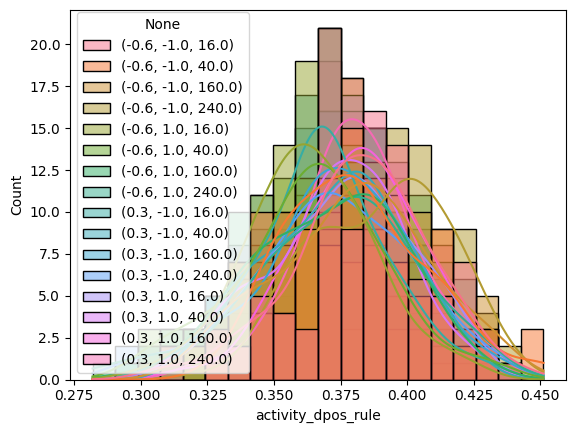

In [61]:
sns.histplot(data=act_df, x='activity_dpos_rule', bins=20, kde=True, hue=act_df[['lim_std', 'd', 'tau_std']].apply(tuple, axis=1))

**MEAN ACTIVITY**

- Effect of lim_std + d
- tau_std has different effects in the different combinations of lim_std + d

<Axes: xlabel='activity_mean', ylabel='Count'>

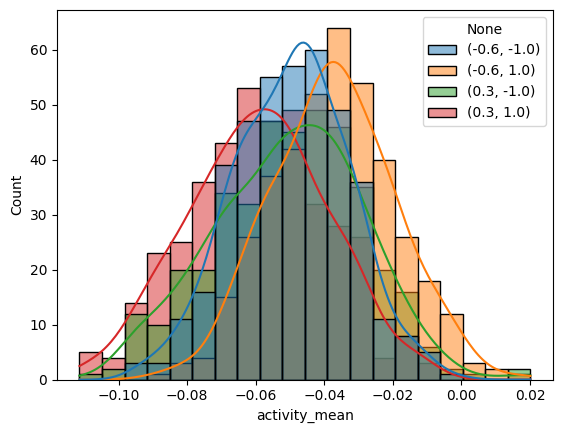

In [64]:
sns.histplot(data=act_df, x='activity_mean', bins=20, kde=True, hue=act_df[['lim_std', 'd']].apply(tuple, axis=1))

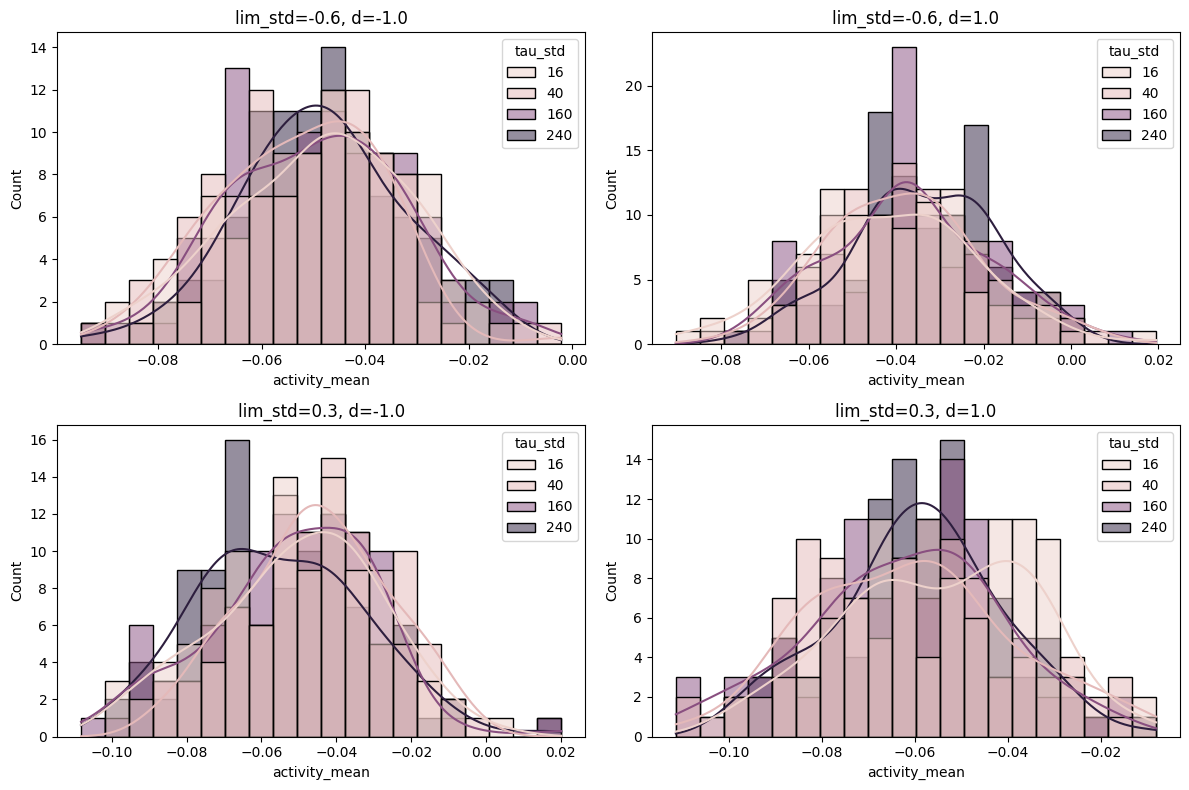

In [78]:
# for each combination of lim_std and d (there are 4 combinations in total), plot a subplot in a figure and put tau_std as a hue in the histogram of activity_mean
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
for i, (lim_std, d) in enumerate(act_df[['lim_std', 'd']].drop_duplicates().values):
    ax = axs[i // 2, i % 2]
    subset = act_df[(act_df['lim_std'] == lim_std) & (act_df['d'] == d)]
    sns.histplot(data=subset, x='activity_mean', bins=20, kde=True, hue='tau_std', ax=ax)
    ax.set_title(f'lim_std={lim_std}, d={d}')
fig.tight_layout()

<Axes: xlabel='activity_mean', ylabel='Count'>

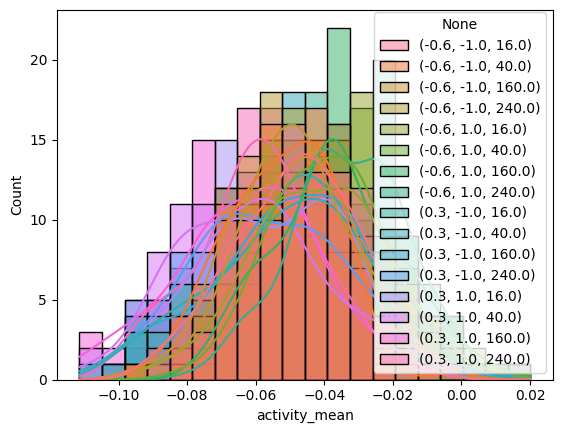

In [ ]:
# cmap = sns.color_palette("Purples", 4) + sns.color_palette("YlOrRd", 4) + sns.color_palette("Blues", 4) + sns.color_palette("Greens", 4)
# sns.histplot(data=act_df, x='activity_mean', bins=20, kde=True, hue=act_df[['lim_std', 'd', 'tau_std']].apply(tuple, axis=1), palette=cmap)

sns.histplot(data=act_df, x='activity_mean', bins=20, kde=True, hue=act_df[['lim_std', 'd', 'tau_std']].apply(tuple, axis=1))

**Check whether average activities that are closest to zero also display activity closest to zero in as many modules pairs as possible**

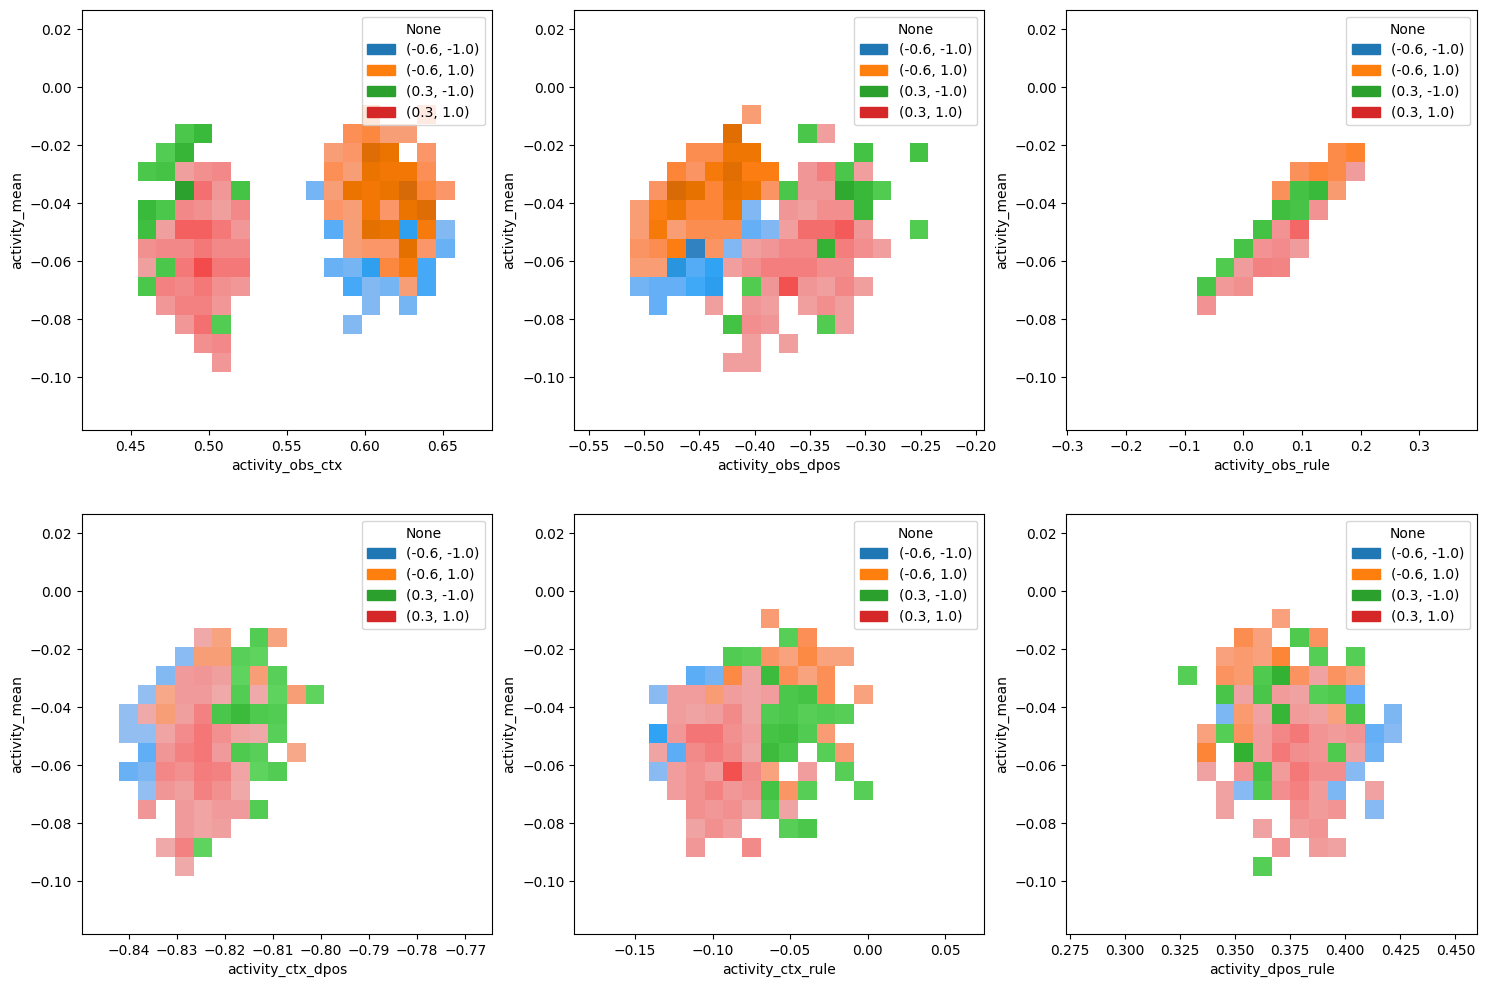

In [91]:
# For each 'activity_obs_ctx', 'activity_obs_dpos', 'activity_obs_rule', 'activity_ctx_dpos', 'activity_ctx_rule', 'activity_dpos_rule', plot a 2D-hist between the selected column and 'activity_mean'
fig, axs = plt.subplots(2, 3, figsize=(18, 12))
activity_columns = ['activity_obs_ctx', 'activity_obs_dpos', 'activity_obs_rule',
                    'activity_ctx_dpos', 'activity_ctx_rule', 'activity_dpos_rule']
for i, col in enumerate(activity_columns):
    ax = axs[i // 3, i % 3]
    sns.histplot(data=act_df, x=col, y='activity_mean', bins=20, pthresh=.1, cmap="mako", ax=ax, hue=act_df[['lim_std', 'd']].apply(tuple, axis=1))
